In [7]:
import sys
from pathlib import Path

root = Path.cwd()

while not (root / 'src').exists() and root != root.parent:
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

In [2]:
from src.data.deeplense_classify import DeepLenseClassifyDataset

In [3]:
deeplense_classify_dataset = DeepLenseClassifyDataset(root_dir=fr"{root}/datasets/deeplense_classify/dataset/train")
len(deeplense_classify_dataset)

30000

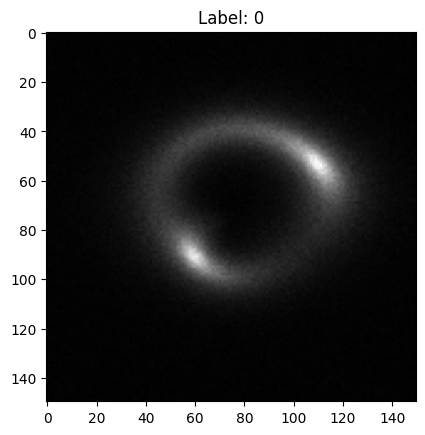

In [4]:
import matplotlib.pyplot as plt

image, label = deeplense_classify_dataset[0]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [5]:
# Loop over all the images and calculate the mean and std
import numpy as np

# means = []
# stds = []
# for i in range(len(deeplense_classify_dataset)):
#     image, _ = deeplense_classify_dataset[i]
#     means.append(image.mean().item())
#     stds.append(image.std().item())
# print(f"Mean: {np.mean(means)}, Std: {np.mean(stds)}")

In [6]:
# Size of the image
print(f"Image shape: {image.shape}")

Image shape: torch.Size([1, 150, 150])


In [7]:
# Let's test the dataloaders
from src.data.deeplense_classify import get_dataloaders
from src.data.deeplense_classify import DataConfig

cfg = DataConfig(
    data_root=fr"{root}/datasets/deeplense_classify/dataset",
    image_size=150,
    batch_size=64,
)

train_loader, val_loader = get_dataloaders(cfg)
print(f"Number of batches in train loader: {len(train_loader)}")

Number of batches in train loader: 469


In [8]:
len(val_loader)

118

In [5]:
import numpy as np
from pathlib import Path

# Grab just the very first file in the directory
data_dir = Path("datasets/deeplense_diffusion/samples")
sample_file = root / data_dir / "sample1.npy"

# Load it and print the stats
img = np.load(sample_file)

print(f"Image Shape: {img.shape}")
print(f"Data Type:   {img.dtype}")
print(f"Min Value:   {img.min():.4f}")
print(f"Max Value:   {img.max():.4f}")

Image Shape: (1, 150, 150)
Data Type:   float64
Min Value:   0.0000
Max Value:   1.0000


Looking for data in: D:\Shreyas\ML4Sci-Deeplense-Diffusion\datasets\deeplense_diffusion/samples

✅ Success!
Total Training Batches: 563
Total Validation Batches: 63

--- Batch Statistics ---
Shape: torch.Size([16, 1, 150, 150])
Min Value (Normalized): 0.0000
Max Value (Normalized): 1.0000
Data Type: torch.float32


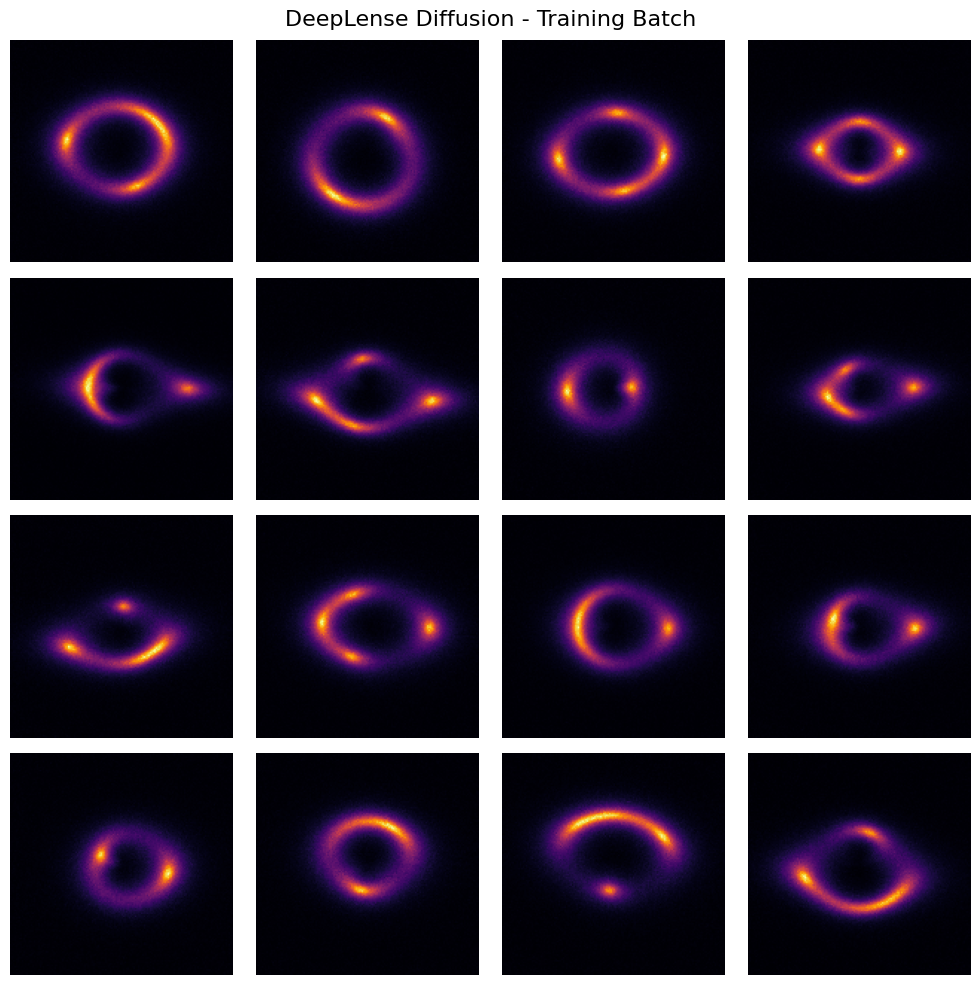

In [ ]:
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# Import your pipeline modules
from src.data.config import DataConfig
from src.data.deeplense_diffusion import get_dataloaders, denormalize

# 1. Mock the Hydra Config
cfg = DataConfig(
    data_root=root / "datasets/deeplense_diffusion",
    image_size=150,
    batch_size=16,
    seed=42
)

print(f"Looking for data in: {Path(cfg.data_root).resolve()}/samples")

# 2. Build the dataloaders
try:
    train_loader, val_loader = get_dataloaders(cfg)
    
    print(f"\n✅ Success!")
    print(f"Total Training Batches: {len(train_loader)}")
    print(f"Total Validation Batches: {len(val_loader)}")
    
    # 3. Fetch a single batch
    images, labels = next(iter(train_loader))
    
    print(f"\n--- Batch Statistics ---")
    print(f"Shape: {images.shape}")
    print(f"Min Value (Normalized): {images.min().item():.4f}")
    print(f"Max Value (Normalized): {images.max().item():.4f}")
    print(f"Data Type: {images.dtype}")
    
    # 4. Denormalize for plotting (shifts [-1, 1] back to [0, 1])
    vis_images = denormalize(images)
    
    # 5. Plot the grid
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    fig.suptitle("DeepLense Diffusion - Training Batch", fontsize=16)
    
    for i, ax in enumerate(axes.flatten()):
        if i < len(vis_images):
            # Squeeze removes the channel dimension for matplotlib (1, 150, 150) -> (150, 150)
            img_np = vis_images[i].squeeze().cpu().numpy()
            ax.imshow(img_np, cmap='inferno') # 'inferno' or 'magma' looks great for astrophysics data
            ax.axis('off')
            
    plt.tight_layout()
    plt.show()

except StopIteration:
    print("\n❌ ERROR: The dataloader is completely empty!")
    print("Check if the .npy files are actually inside 'datasets/deeplense_diffusion/samples'")
except Exception as e:
    print(f"\n❌ ERROR: {e}")